# ML & Clustering Analysis

This notebook carries out the machine learning and clustering part of the project.  
The first objective is to predict player market value from on-pitch performance indicators.  
The second objective is to group players into performance archetypes using clustering.

The analysis focuses on the cleaned master dataset prepared by P1, which already merges StatsBomb performance data with Transfermarkt market values.

## 1. Load the dataset

We start by loading the final merged dataset produced by the data engineering step.  
This file is already cleaned and filtered, so we can focus on modelling and interpretation rather than raw data preparation.

In [5]:
import pandas as pd

df = pd.read_csv("sample_data/j1_player_value_statsbomb_merged.csv")

df.head()

,player_id,player_name,team_name,minutes_played,goals,assists,shots,xG,xA,key_passes,...,completed_passes_per90,progressive_passes_per90,pressures_per90,interceptions_per90,tackles_per90,dribbles_per90,successful_dribbles_per90,market_value_eur,market_value_raw,log_market_value
0,38523,Jin-Hyeon Kim,Cerezo Osaka,3677,0.0,0.0,1.0,0.0494,0.1716,4.0,...,20.707098,25.259723,0.048953,0.000000,0.024476,0.048953,0.048953,100000.0,€100k,11.512925
1,37514,Jun Ichimori,Gamba Osaka,3671,0.0,0.0,0.0,0.0000,0.0000,0.0,...,24.982294,24.369382,0.049033,0.000000,0.000000,0.049033,0.049033,300000.0,€300k,12.611538
2,37121,Shinnosuke Nakatani,Gamba Osaka,3671,4.0,0.0,21.0,3.1186,0.7951,7.0,...,47.684555,23.413239,6.374285,0.710978,0.882593,0.171615,0.171615,1300000.0,€1.30m,14.077875
3,126936,Tomoki Hayakawa,Kashima Antlers,3656,0.0,0.0,0.0,0.0000,0.0899,1.0,...,23.115427,27.644967,0.073851,0.000000,0.000000,0.049234,0.049234,1500000.0,€1.50m,14.220976
4,38272,Keisuke Osako,Sanfrecce Hiroshima,3649,0.0,0.0,0.0,0.0000,0.0125,1.0,...,13.072075,21.729241,0.024664,0.000000,0.000000,0.049329,0.024664,2000000.0,€2.00m,14.508658


In [6]:
df.columns

Index(['player_id', 'player_name', 'team_name', 'minutes_played', 'goals',
       'assists', 'shots', 'xG', 'xA', 'key_passes', 'passes',
       'completed_passes', 'progressive_passes', 'pressures', 'interceptions',
       'tackles', 'dribbles', 'successful_dribbles', 'pass_completion_pct',
       'goals_per90', 'shots_per90', 'xG_per90', 'xA_per90',
       'key_passes_per90', 'assists_per90', 'passes_per90',
       'completed_passes_per90', 'progressive_passes_per90', 'pressures_per90',
       'interceptions_per90', 'tackles_per90', 'dribbles_per90',
       'successful_dribbles_per90', 'market_value_eur', 'market_value_raw',
       'log_market_value'],
      dtype='object')

## 2. Feature selection and target variable

For the regression model, we use only performance-based variables, especially the per90 metrics.  
These are preferable because they normalize player output by playing time, making players more comparable.

We exclude identifiers such as player name or team name, as they do not directly explain market value.  
We also exclude the target variable itself from the features to avoid data leakage.

The target of the model is `log_market_value`.  
Using a log transformation helps reduce the impact of extreme values and makes the distribution more suitable for modelling.

This approach is more stable than predicting raw market value directly, since transfer values tend to be highly skewed.

In [7]:
# Target
y = df["log_market_value"]

# Features
features = [
    'goals_per90', 'assists_per90', 'shots_per90',
    'xG_per90', 'xA_per90', 'key_passes_per90',
    'passes_per90', 'completed_passes_per90',
    'progressive_passes_per90', 'pressures_per90',
    'interceptions_per90', 'tackles_per90',
    'dribbles_per90', 'successful_dribbles_per90'
]

X = df[features]

## 4. Train-test split

We split the dataset into training and test sets so we can evaluate the model on unseen players.  
This gives us a more realistic estimate of how well the model generalizes.

A fixed random state is used to make the results reproducible.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Baseline model: Linear Regression

We begin with a simple linear regression model to establish a benchmark.  
This model assumes a mostly linear relationship between performance statistics and market value.

If performance is weak, that is still useful: it suggests that player value is not explained well by a simple linear pattern and that more complex interactions may be needed.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 1.036897741559025
R2: -0.40760093926643526


## **6. Baseline evaluation**

The baseline model produces a negative R², which means it performs worse than simply predicting the average market value for every player.

This result shows that a linear relationship is not enough to explain market value accurately.  
In football terms, player valuation is likely influenced by non-linear effects, positional differences, team context, reputation, age, and other factors not captured in the current feature set.

## 7. Improved model: Random Forest

To capture non-linear relationships and interactions between variables, we next use a Random Forest regressor.  
This model is more flexible than linear regression and can handle complex patterns in the data.

We tune the model with sensible parameter choices instead of relying on defaults, because the project rubric values deliberate modelling decisions.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE RF:", rmse_rf)
print("R2 RF:", r2_rf)

RMSE RF: 0.8987183802634862
R2 RF: -0.05743806176499766


In [13]:
print("Baseline Linear Regression")
print("RMSE:", rmse)
print("R2:", r2)

print("\nRandom Forest")
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Baseline Linear Regression
RMSE: 1.036897741559025
R2: -0.40760093926643526

Random Forest
RMSE: 0.8987183802634862
R2: -0.05743806176499766


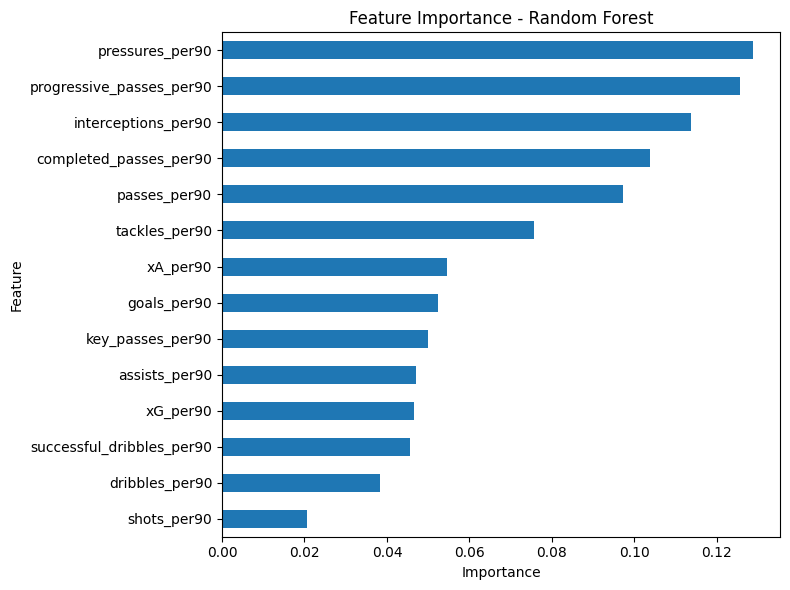

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(8, 6))
feat_importance.plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Importance Interpretation

The feature importance analysis reveals which performance metrics are most influential in explaining player market value.

Interestingly, the most important variables are not purely attacking metrics. Instead, we observe that:

- **Pressures per90** and **progressive passes per90** are among the top features. This suggests that players who contribute to pressing and ball progression are highly valued.
- **Interceptions and defensive actions** also rank highly, indicating that defensive contributions play a significant role in market valuation.
- Traditional attacking metrics such as **goals, xG, and assists** are important, but not dominant.

This result suggests that the market does not reward only goal-scoring ability, but rather a more complete player profile, including defensive work and build-up play.

However, it is important to note that the overall predictive power of the model remains low (negative R²). This indicates that performance statistics alone are not sufficient to explain market value.

Other factors not included in the dataset — such as age, position, reputation, team success, or future potential — likely play a crucial role in determining a player's valuation.

Overall, this analysis suggests that while performance contributes to market value, it is only one part of a much more complex valuation process.

## 8. Clustering player profiles

After the regression analysis, we use K-Means clustering to group players with similar performance profiles.  
This helps us identify player archetypes rather than predicting a single target value.

The goal is to see whether players fall into clear performance groups such as attacking creators, defensive specialists, or balanced all-rounders.


In [15]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    'goals_per90', 'assists_per90', 'shots_per90',
    'xG_per90', 'xA_per90', 'key_passes_per90',
    'passes_per90', 'completed_passes_per90',
    'progressive_passes_per90', 'pressures_per90',
    'interceptions_per90', 'tackles_per90',
    'dribbles_per90', 'successful_dribbles_per90'
]

cluster_df = df[['player_name', 'team_name'] + cluster_features].dropna().copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

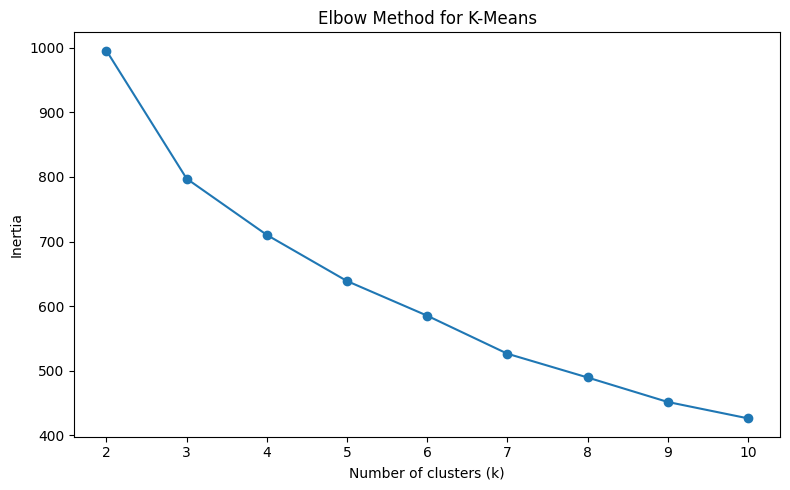

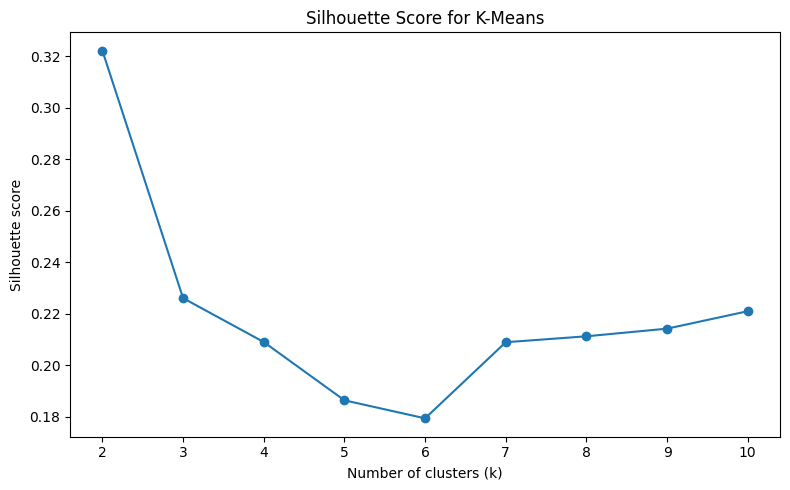

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouettes, marker='o')
plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

## Choosing the number of clusters

The elbow method does not show a very sharp bend, but the curve starts to flatten around k = 4–5.  
The silhouette score is highest for k = 2, but this would result in an overly simplistic segmentation of players.

We therefore choose k = 4 as a balance between interpretability and cluster quality.  
This allows us to identify multiple meaningful player archetypes while maintaining reasonable separation between clusters.

In [17]:
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(X_cluster)

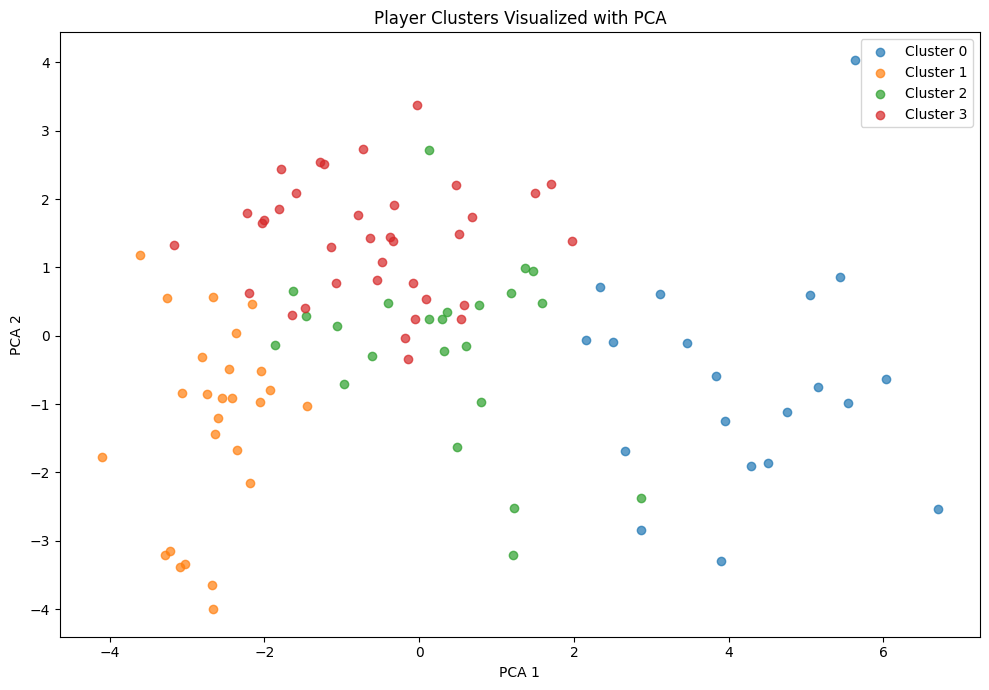

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

cluster_df['pca_1'] = X_pca[:, 0]
cluster_df['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
for c in sorted(cluster_df['cluster'].unique()):
    subset = cluster_df[cluster_df['cluster'] == c]
    plt.scatter(subset['pca_1'], subset['pca_2'], label=f'Cluster {c}', alpha=0.7)

plt.title("Player Clusters Visualized with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.show()

## Cluster visualization interpretation

The PCA visualization shows a reasonable separation between clusters, although some overlap exists.  
This is expected in football data, as player roles often blend rather than forming completely distinct groups.

The clusters appear to capture different playing styles rather than strictly separated categories, which aligns with the complexity of player roles in modern football.

In [19]:
distances = kmeans.transform(X_cluster)

cluster_df['distance_to_cluster'] = [
    distances[i, cluster_df.iloc[i]['cluster']] for i in range(len(cluster_df))
]

for c in sorted(cluster_df['cluster'].unique()):
    print(f"\nCluster {c}")
    display(
        cluster_df[cluster_df['cluster'] == c]
        .sort_values('distance_to_cluster')
        [['player_name', 'team_name']]
        .head(5)
    )


Cluster 0


,player_name,team_name
21,Mutsuki Kato,Sanfrecce Hiroshima
23,Yoshinori Muto,Vissel Kobe
20,Yuma Suzuki,Kashima Antlers
66,Jun Amano,Yokohama F. Marinos
38,Mao Hosoya,Kashiwa Reysol



Cluster 1


,player_name,team_name
9,Taiyo Koga,Kashiwa Reysol
14,Tetsushi Yamakawa,Vissel Kobe
5,Naomichi Ueda,Kashima Antlers
10,Ikuma Sekigawa,Kashima Antlers
46,Tomoya Inukai,Kashiwa Reysol



Cluster 2


,player_name,team_name
60,Yosuke Ideguchi,Vissel Kobe
93,Shu Kurata,Gamba Osaka
91,Takumi Tsuchiya,Kashiwa Reysol
58,Masato Shigemi,Avispa Fukuoka
61,Yota Maejima,Avispa Fukuoka



Cluster 3


,player_name,team_name
73,Ren Kato,Yokohama F. Marinos
8,Shunta Tanaka,Cerezo Osaka
69,Sachiro Toshima,Kashiwa Reysol
75,Gaku Shibasaki,Kashima Antlers
67,Hayato Okuda,Cerezo Osaka


In [20]:
cluster_df.groupby("cluster")[cluster_features].mean()

,goals_per90,assists_per90,shots_per90,xG_per90,xA_per90,key_passes_per90,passes_per90,completed_passes_per90,progressive_passes_per90,pressures_per90,interceptions_per90,tackles_per90,dribbles_per90,successful_dribbles_per90
cluster,,,,,,,,,,,,,,
0,0.268267,0.177733,2.453614,0.257734,0.143601,1.213497,29.616537,20.752082,7.325138,16.447775,0.394654,1.008708,1.874071,0.860038
1,0.034330,0.014132,0.334134,0.026620,0.015569,0.167724,42.027779,32.659734,21.410040,5.445169,0.659383,0.841485,0.143520,0.100079
2,0.075936,0.036001,1.230251,0.105344,0.053041,0.615498,34.794992,26.779077,10.313785,16.893130,0.873985,1.879973,0.881362,0.419603
3,0.060101,0.098830,0.866637,0.052071,0.097068,1.020011,51.047416,41.069174,16.769910,12.883732,0.956526,1.531570,0.787932,0.427751


## Cluster interpretation

By analyzing the average performance metrics within each cluster, we can identify distinct player archetypes:

- **Cluster 0 – Attacking contributors**
  This group shows the highest values in attacking metrics such as goals, shots, xG, and assists.  
  These players also contribute moderately in pressing and passing, suggesting they are offensive players who are actively involved in finishing and chance creation.

- **Cluster 1 – Deep playmakers / possession players**
  Players in this cluster have the highest values in passing-related metrics (passes and completed passes) and progressive passes.  
  However, they show very low attacking output. This suggests they are more focused on ball circulation and build-up play rather than direct goal contribution.

- **Cluster 2 – Defensive specialists**
  This group stands out in defensive metrics such as interceptions, tackles, and pressures.  
  Their attacking contribution is relatively low, indicating that these players primarily focus on defensive duties and ball recovery.

- **Cluster 3 – Balanced all-rounders**
  Players in this cluster show relatively balanced values across attacking, passing, and defensive metrics.  
  They are not extreme in any single dimension, which suggests they play versatile roles and contribute in multiple phases of the game.

Overall, the clustering analysis reveals that players can be grouped into meaningful performance profiles.  
Importantly, these profiles are not purely offensive or defensive, but reflect different roles within a team structure.

This supports the idea that player value cannot be explained by a single type of performance, but rather depends on a combination of role, contribution, and context.

## Identifying Overvalued and Undervalued Players

To further explore the relationship between performance and market value, we compare each player’s actual market value with the value predicted by our Random Forest model.

The difference between these two values (the residual) provides an indication of whether a player is priced above or below what their on-pitch performance would suggest.

This approach allows us to identify players who may be relatively overvalued or undervalued, while keeping in mind the limitations of the model.

In [21]:
# Predicción sobre TODO el dataset
df["predicted_value"] = rf.predict(X)

# Diferencia entre valor real y predicho
df["residual"] = df["log_market_value"] - df["predicted_value"]

In [22]:
# Overrated (más valor del esperado)
overrated = df.sort_values("residual", ascending=False)[
    ["player_name", "team_name", "log_market_value", "predicted_value", "residual"]
].head(5)

# Underrated (menos valor del esperado)
underrated = df.sort_values("residual", ascending=True)[
    ["player_name", "team_name", "log_market_value", "predicted_value", "residual"]
].head(5)

print("Top Overrated Players")
display(overrated)

print("\nTop Underrated Players")
display(underrated)

Top Overrated Players


,player_name,team_name,log_market_value,predicted_value,residual
4,Keisuke Osako,Sanfrecce Hiroshima,14.508658,12.808178,1.700480
89,Hayao Kawabe,Sanfrecce Hiroshima,14.914123,13.367042,1.547081
65,Sota Miura,Kawasaki Frontale,13.997832,12.948951,1.048881
31,Yasuto Wakizaka,Kawasaki Frontale,14.220976,13.189530,1.031446
77,Aleksandar Čavrić,Kashima Antlers,14.151983,13.307410,0.844573



Top Underrated Players


,player_name,team_name,log_market_value,predicted_value,residual
0,Jin-Hyeon Kim,Cerezo Osaka,11.512925,13.422495,-1.909569
96,Genta Miura,Gamba Osaka,12.206073,13.398955,-1.192882
12,Sho Sasaki,Sanfrecce Hiroshima,12.429216,13.457270,-1.028054
86,Hiroki Iikura,Yokohama F. Marinos,10.819778,11.777509,-0.957731
104,Shinji Kagawa,Cerezo Osaka,12.072541,12.880934,-0.808392


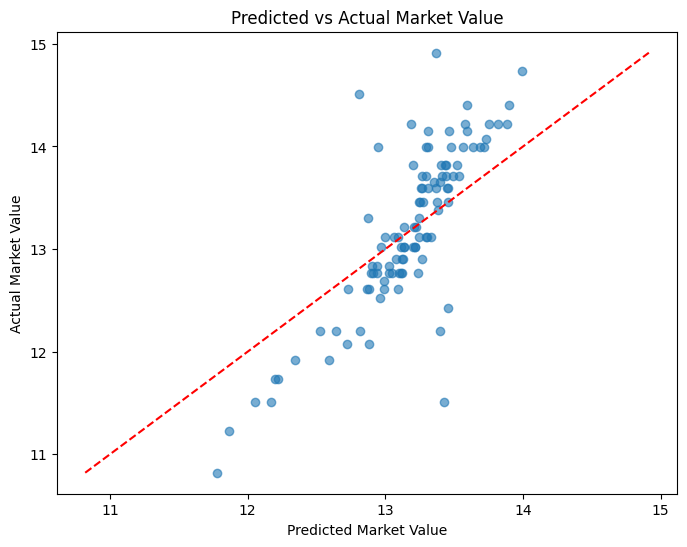

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["predicted_value"], df["log_market_value"], alpha=0.6)

plt.xlabel("Predicted Market Value")
plt.ylabel("Actual Market Value")
plt.title("Predicted vs Actual Market Value")

# línea perfecta
min_val = min(df["predicted_value"].min(), df["log_market_value"].min())
max_val = max(df["predicted_value"].max(), df["log_market_value"].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.show()

## Interpretation of Results

The results show a clear gap between predicted and actual market values for several players.

Players with the highest positive residuals (such as Keisuke Osako and Hayao Kawabe) appear to be valued above what their performance metrics would suggest. This could be due to factors not captured in the dataset, such as reputation, age, potential, or team context.

On the other hand, players with strong negative residuals (such as Jin-Hyeon Kim and Genta Miura) seem to be undervalued relative to their performance. These players may be contributing significantly on the pitch without receiving equivalent recognition in market value.

The scatter plot further supports this interpretation. While there is a general positive relationship between predicted and actual values, there is noticeable dispersion around the diagonal line. This indicates that performance alone does not fully explain market value.

Overall, this analysis suggests that the football transfer market is not purely performance-driven. Instead, market value appears to be influenced by a combination of measurable performance and external factors not included in the model.